# 01 — Download and Explore the Dataset

This notebook:
1. Downloads the latest version of the Kaggle dataset using `kagglehub`.
2. Finds all CSV files automatically.
3. Inspects shapes, columns, missing values, and data types.
4. Suggests likely target or label columns.
5. Produces basic class-distribution and correlation plots.
6. Saves a schema summary for the training notebook.

Dataset:
The `thashmiladewmini/squat-exercise-pose-dataset` contains pose-based features extracted from squat exercise videos. Each record represents a single video frame and includes joint-angle measurements and other posture-related features. The dataset is labelled with posture classes, making it suitable for training and evaluating machine learning models for squat posture classification.

In [1]:
from pathlib import Path
import json

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATASET_HANDLE = "thashmiladewmini/squat-exercise-pose-dataset"

PROJECT_DIR = Path.cwd()
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Working directory:", PROJECT_DIR)

Working directory: C:\Users\boale\Deep Neural Engineering


## 1. Download the dataset

In [2]:
dataset_path = Path(
    kagglehub.dataset_download(DATASET_HANDLE)
)

print("Dataset folder:", dataset_path)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2.27M/2.27M [00:00<00:00, 3.82MB/s]


Extracting files...
Dataset folder: C:\Users\boale\.cache\kagglehub\datasets\thashmiladewmini\squat-exercise-pose-dataset\versions\1


In [3]:
files_found = sorted(
    path for path in dataset_path.rglob("*")
    if path.is_file()
)

print(f"Found {len(files_found)} files:")

for path in files_found:
    relative_path = path.relative_to(dataset_path)
    size_kb = path.stat().st_size / 1024
    print(f" - {relative_path} ({size_kb:.1f} KB)")

Found 2 files:
 - squat_dataset\README.md (2.7 KB)
 - squat_dataset\squat_features_augmented.csv (10994.6 KB)


## 2. Load all CSV files


In [4]:
csv_files = sorted(dataset_path.rglob("*.csv"))

if not csv_files:
    raise FileNotFoundError(
        f"No CSV files were found in {dataset_path}"
    )

dataframes = {}

for csv_path in csv_files:
    try:
        dataframe = pd.read_csv(csv_path)
    except UnicodeDecodeError:
        dataframe = pd.read_csv(csv_path, encoding="latin-1")

    key = str(csv_path.relative_to(dataset_path))
    dataframes[key] = dataframe

    print(
        f"{key}: "
        f"{dataframe.shape[0]:,} rows × "
        f"{dataframe.shape[1]:,} columns"
    )

squat_dataset\squat_features_augmented.csv: 47,442 rows × 15 columns


In [5]:
for filename, dataframe in dataframes.items():
    print("\n" + "=" * 90)
    print(filename)
    display(dataframe.head())


squat_dataset\squat_features_augmented.csv


,left_knee_angle,right_knee_angle,left_hip_angle,right_hip_angle,left_ankle_angle,right_ankle_angle,spine_angle,torso_lean,left_knee_lateral,right_knee_lateral,symmetry_score,hip_depth,video_file,frame,label
0,120.254411,102.110289,149.682786,141.059426,77.30243,70.434401,149.682786,95.286652,0.077956,0.090834,26.767481,0.444815,co1.mp4,0,0
1,132.223949,116.930256,164.205496,146.066398,77.30243,70.434401,149.682786,95.286652,0.077956,0.090834,26.767481,0.444815,co1.mp4,0,1
2,120.254411,102.110289,149.682786,141.059426,77.30243,70.434401,139.120795,108.975838,0.077956,0.090834,26.767481,0.444815,co1.mp4,0,2
3,102.034287,83.887751,149.682786,141.059426,77.30243,70.434401,149.682786,95.286652,0.121875,0.140702,26.767481,0.444815,co1.mp4,0,3
4,120.254411,102.110289,149.682786,141.059426,101.23405,84.996304,149.682786,95.286652,0.077956,0.090834,26.767481,0.444815,co1.mp4,0,4


## 3. Inspect the schema

This section examines the structure of the dataset by summarising each column. For every feature, the data type, number of missing values, percentage of missing values, number of unique values and an example value are recorded. This helps verify the quality of the dataset and identify suitable features for model training.

In [6]:
schema_rows = []

for filename, dataframe in dataframes.items():
    for column in dataframe.columns:
        non_missing = dataframe[column].dropna()

        schema_rows.append({
            "file": filename,
            "column": column,
            "dtype": str(dataframe[column].dtype),
            "missing": int(dataframe[column].isna().sum()),
            "missing_pct": round(
                100 * dataframe[column].isna().mean(),
                2
            ),
            "unique": int(
                dataframe[column].nunique(dropna=True)
            ),
            "example": (
                None
                if non_missing.empty
                else str(non_missing.iloc[0])[:100]
            ),
        })

schema_df = pd.DataFrame(schema_rows)

display(schema_df)

schema_output = PROCESSED_DIR / "schema_summary.csv"
schema_df.to_csv(schema_output, index=False)

print("Saved schema to:", schema_output)

,file,column,dtype,missing,missing_pct,unique,example
0,squat_dataset\squat_features_augmented.csv,left_knee_angle,float64,0,0.0,31628,120.25441059777776
1,squat_dataset\squat_features_augmented.csv,right_knee_angle,float64,0,0.0,31628,102.11028912512754
2,squat_dataset\squat_features_augmented.csv,left_hip_angle,float64,0,0.0,23721,149.682785536512
3,squat_dataset\squat_features_augmented.csv,right_hip_angle,float64,0,0.0,23721,141.05942587684194
4,squat_dataset\squat_features_augmented.csv,left_ankle_angle,float64,0,0.0,15814,77.30243046802455
5,squat_dataset\squat_features_augmented.csv,right_ankle_angle,float64,0,0.0,15814,70.4344005166391
6,squat_dataset\squat_features_augmented.csv,spine_angle,float64,0,0.0,15814,149.682785536512
7,squat_dataset\squat_features_augmented.csv,torso_lean,float64,0,0.0,15814,95.28665214041132
8,squat_dataset\squat_features_augmented.csv,left_knee_lateral,float64,0,0.0,15798,0.0779562592506408
9,squat_dataset\squat_features_augmented.csv,right_knee_lateral,float64,0,0.0,15804,0.0908343493938446


Saved schema to: C:\Users\boale\Deep Neural Engineering\data\processed\schema_summary.csv


## 4. Suggest likely label columns and plot label distributions


In [7]:
TARGET_HINTS = {
    "label",
    "class",
    "target",
    "category",
    "posture",
    "pose",
    "status",
    "correct",
    "quality",
    "type",
    "exercise",
}

candidate_targets = []

for filename, dataframe in dataframes.items():
    for column in dataframe.columns:
        column_lower = column.lower()
        unique_count = dataframe[column].nunique(dropna=True)

        name_score = int(
            any(hint in column_lower for hint in TARGET_HINTS)
        )

        categorical_score = int(
            pd.api.types.is_object_dtype(dataframe[column])
            or pd.api.types.is_bool_dtype(dataframe[column])
            or isinstance(
                dataframe[column].dtype,
                pd.CategoricalDtype
            )
        )

        manageable_classes = int(
            2 <= unique_count <= min(
                30,
                max(2, len(dataframe) // 5)
            )
        )

        score = (
            3 * name_score
            + 2 * categorical_score
            + manageable_classes
        )

        if score > 0:
            candidate_targets.append(
                (score, filename, column, unique_count)
            )

candidate_targets = sorted(
    candidate_targets,
    reverse=True
)

print("Likely target columns:")

for score, filename, column, unique_count in candidate_targets[:20]:
    print(
        f" score={score} | "
        f"{filename} | "
        f"{column!r} | "
        f"{unique_count} unique values"
    )

Likely target columns:
 score=4 | squat_dataset\squat_features_augmented.csv | 'label' | 6 unique values
 score=3 | squat_dataset\squat_features_augmented.csv | 'video_file' | 15 unique values


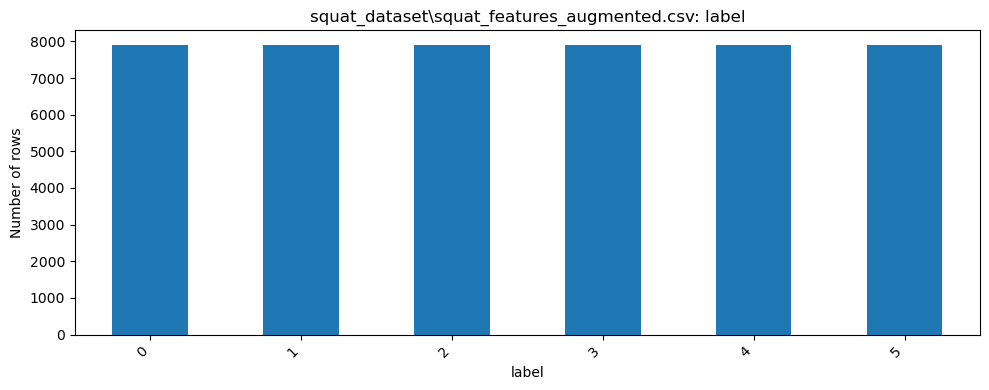

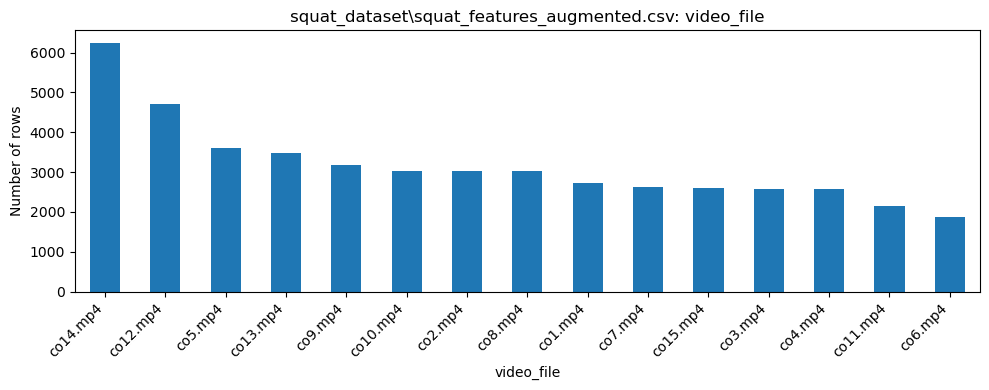

In [8]:
for _, filename, column, unique_count in candidate_targets[:8]:
    if unique_count > 30:
        continue

    counts = (
        dataframes[filename][column]
        .astype(str)
        .value_counts(dropna=False)
    )

    ax = counts.plot(
        kind="bar",
        figsize=(10, 4),
        title=f"{filename}: {column}",
    )

    ax.set_xlabel(column)
    ax.set_ylabel("Number of rows")

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 5. Numeric summaries and correlations


squat_dataset\squat_features_augmented.csv: 14 numeric columns


,count,mean,std,min,25%,50%,75%,max
left_knee_angle,47442.0,67.744184,43.870149,-10.292159,28.003012,57.199251,108.225420,196.394461
right_knee_angle,47442.0,64.960356,41.907424,-8.127170,27.145303,54.674684,104.021060,191.984174
left_hip_angle,47442.0,88.198611,49.268002,0.228501,40.042545,94.216476,133.644561,191.408690
right_hip_angle,47442.0,87.963258,49.890513,0.544477,38.878752,91.199939,134.606683,183.625383
left_ankle_angle,47442.0,42.456373,18.081762,16.561197,30.613706,38.342275,48.736538,192.728908
right_ankle_angle,47442.0,41.784775,17.113977,17.225404,29.836656,37.599504,48.569917,200.641039
spine_angle,47442.0,84.849897,49.220265,-6.091643,36.960895,90.893801,130.265677,177.363387
torso_lean,47442.0,99.993345,12.350453,15.062896,91.681297,100.272579,107.805114,161.598079
left_knee_lateral,47442.0,0.100566,0.046631,0.000277,0.064370,0.098531,0.129657,0.264719
right_knee_lateral,47442.0,0.090769,0.047493,0.001745,0.053336,0.083425,0.125592,0.299773


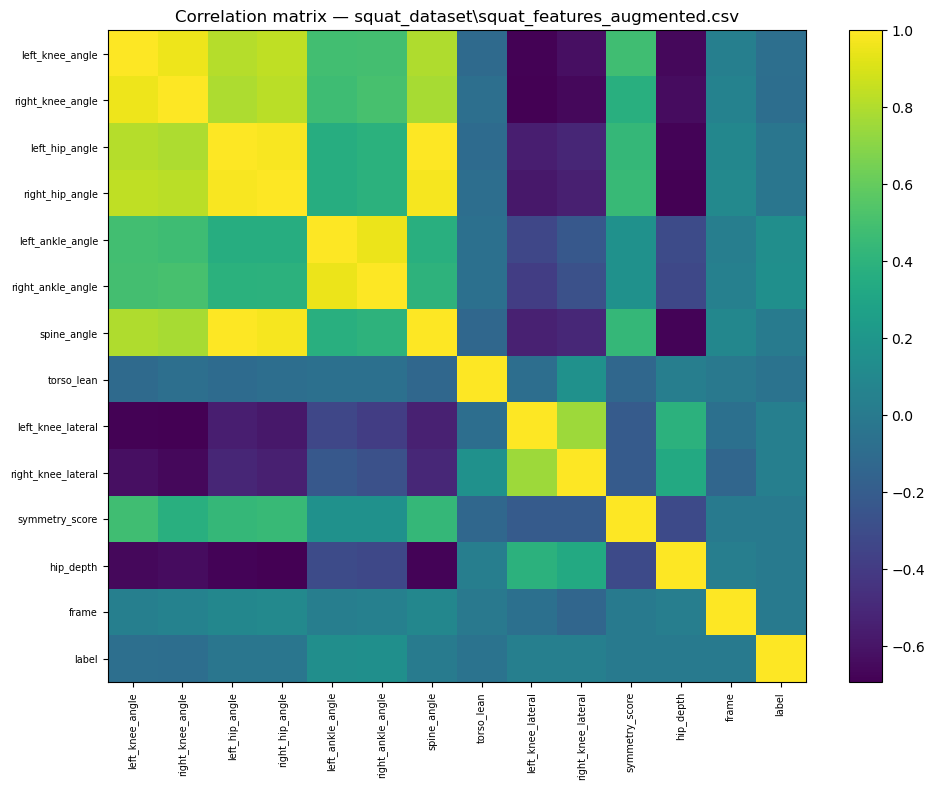

In [9]:
for filename, dataframe in dataframes.items():
    numeric = dataframe.select_dtypes(include=np.number)

    print(
        f"\n{filename}: "
        f"{numeric.shape[1]} numeric columns"
    )

    if numeric.shape[1] == 0:
        continue

    display(numeric.describe().T)

    selected_columns = numeric.columns[:25]
    correlation = numeric[selected_columns].corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    image = ax.imshow(correlation, aspect="auto")

    ax.set_xticks(range(len(selected_columns)))
    ax.set_yticks(range(len(selected_columns)))

    ax.set_xticklabels(
        selected_columns,
        rotation=90,
        fontsize=7
    )

    ax.set_yticklabels(
        selected_columns,
        fontsize=7
    )

    fig.colorbar(image, ax=ax)
    ax.set_title(f"Correlation matrix — {filename}")

    plt.tight_layout()
    plt.show()

## 6. Saving a schema summary for the training notebook

In [10]:
manifest = {
    "dataset_handle": DATASET_HANDLE,
    "dataset_path": str(dataset_path),
    "csv_files": [
        str(path.relative_to(dataset_path))
        for path in csv_files
    ],
    "candidate_targets": [
        {
            "score": int(score),
            "file": filename,
            "column": column,
            "unique": int(unique_count),
        }
        for score, filename, column, unique_count
        in candidate_targets
    ],
}

manifest_output = PROCESSED_DIR / "manifest.json"

manifest_output.write_text(
    json.dumps(manifest, indent=2)
)

print(json.dumps(manifest, indent=2))
print("\nSaved manifest to:", manifest_output)

{
  "dataset_handle": "thashmiladewmini/squat-exercise-pose-dataset",
  "dataset_path": "C:\\Users\\boale\\.cache\\kagglehub\\datasets\\thashmiladewmini\\squat-exercise-pose-dataset\\versions\\1",
  "csv_files": [
    "squat_dataset\\squat_features_augmented.csv"
  ],
  "candidate_targets": [
    {
      "score": 4,
      "file": "squat_dataset\\squat_features_augmented.csv",
      "column": "label",
      "unique": 6
    },
    {
      "score": 3,
      "file": "squat_dataset\\squat_features_augmented.csv",
      "column": "video_file",
      "unique": 15
    }
  ]
}

Saved manifest to: C:\Users\boale\Deep Neural Engineering\data\processed\manifest.json
